In [1]:
import time
from time import sleep, monotonic
import datetime
import numpy as np
import matplotlib.pyplot as plt
import sys
import pyvisa
import qcodes as qc
from qcodes.dataset import Measurement
from qcodes.dataset import do0d
from qcodes.dataset.experiment_container import new_experiment, load_experiment_by_name
from qcodes.dataset.plotting import plot_by_id
from qcodes.dataset.data_set import load_by_id, load_by_counter
from qcodes import initialise_or_create_database_at, new_data_set, new_experiment
from qcodes.station import Station
initialise_or_create_database_at("./2026-03-10_SNSPD4.db")
from functions import photon_number
from functions import make_title
import snspd
params = snspd.snspd()

# Set up experiment
exp_name = 'SNSPD4_23_03_2026'
sample_name = '00'

try:
    exp = qc.load_experiment_by_name(exp_name, sample=sample_name)
    print('Experiment loaded. Last ID no:', exp.last_counter)
except ValueError:
    exp = new_experiment(exp_name, sample_name)
    print('Started new experiment')

Logging hadn't been started.
Activating auto-logging. Current session state plus future input saved.
Filename       : C:\Users\QNL\.qcodes\logs\command_history.log
Mode           : append
Output logging : True
Raw input log  : False
Timestamping   : True
State          : active
Qcodes Logfile : C:\Users\QNL\.qcodes\logs\260413-33548-qcodes.log
Experiment loaded. Last ID no: 464


In [3]:
from functions import laser_set_standard



In [ ]:
v_attenuator = 4.7
wavelength_range = np.arange(1528e-9, 1565e-9, step) 

ID =  165 # need to update this to read in from new config file
datasaver.dataset.add_metadata("att_screw_calibration_id", ID)
data = load_by_id(ID).get_parameter_data()
avg_attenuation_screw = np.average(data['attenuation']['attenuation'])

ID = 459
datasaver.dataset.add_metadata("att_combined_id", ID)
data = load_by_id(ID).get_parameter_data()
# Extract attenuator voltages 
v_attenuator = data['v_attenuator']['v_attenuator']
avg_attenuation = data['avg_attenuation']['avg_attenuation']
avg_power90 = data['avg_power90']['avg_power90']

total_attenuation=avg_attenuation + avg_attenuation_screw

Nphotons = photon_number(params.bs10, params.bs90, power90=avg_power90, total_attenuation=total_attenuation, wavelength=1550e-9)

In [11]:
# meas = Measurement()
# meas.register_custom_parameter("v_attenuator", label="V")
# meas.register_custom_parameter("total_attenuation", label="dB")
# meas.register_custom_parameter("Nphotons", label="")

with meas.run() as datasaver: 
    print(datasaver.run_id)

    ID =  params.att_screw_calibration_id
    datasaver.dataset.add_metadata("att_screw_calibration_id", ID)
    data = load_by_id(ID).get_parameter_data()
    avg_attenuation_screw = np.average(data['attenuation']['attenuation'])
    
    ID = params.att_blue_calibration_avg_id
    datasaver.dataset.add_metadata("att_combined_id", ID)
    data = load_by_id(ID).get_parameter_data()
    # Extract attenuator voltages 
    v_attenuator = data['v_attenuator']['v_attenuator']
    avg_attenuation = data['avg_attenuation']['avg_attenuation']
    avg_power90 = data['avg_power90']['avg_power90']
    
    total_attenuation=avg_attenuation + avg_attenuation_screw
    
    Nphotons = photon_number(params.bs10, params.bs90, power90=avg_power90, total_attenuation=total_attenuation, wavelength=1550e-9)
    

    # for i in range(len(v_attenuator)): 
    #     datasaver.add_result(("v_attenuator", v_attenuator[i]),
    #                      ("total_attenuation", total_attenuation[i]),
    #                     ("Nphotons", Nphotons[i]))

Starting experimental run with id: 457. 
457


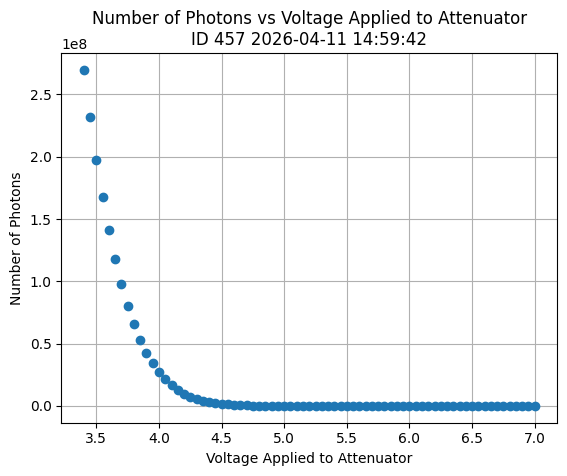

In [8]:
ID = params.att_info_id
data = load_by_id(ID).get_parameter_data()
v_attenuator = data['v_attenuator']['v_attenuator']
Nphotons = data['Nphotons']['Nphotons']
title = f'Number of Photons vs Voltage Applied to Attenuator'
ts = make_title(title, ID, extra=None)
plt.plot(v_attenuator, Nphotons, 'o')
plt.title(ts)
plt.ylabel('Number of Photons')
plt.xlabel('Voltage Applied to Attenuator')
plt.grid()